## Creates the **Grid File** of a specific region by converting the available shapefile into mutliple (X,Y) coordinate pairs to represent each LAU1 Unit ##

In [1]:
import pandas as pd
import random
import geopandas as gpd
import numpy as np

import sys

sys.path.insert(0, "../../../Modules")

from utils import *

enc = 'utf-8'
dec = 'greek8'

random.seed(0)
np.random.seed(0)

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_EL = 'αττικης'

In [3]:
## Reading shapefiles from Greece
folder_path = "C:/Users/dimit/Documents/noa hoard/Greece Shapefiles"

greece_gdf = gpd.read_file(f"{folder_path}/elladitsa.shp",  encoding=enc)
greece_regions_gdf = gpd.read_file(f"{folder_path}/perifereies2.shp",  encoding=enc)
rivers_gdf = gpd.read_file(f"{folder_path}/potamoi2.shp", encoding=enc)

In [4]:
greece_gdf.head(5)

,NAME,KWD_YPES,geometry
0,Αμυνταίου,9070,"POLYGON ((21.70746 40.85172, 21.70955 40.85119..."
1,Άθως,None,"MULTIPOLYGON (((24.25167 40.30363, 24.25149 40..."
2,Άκτιου - Βόνιτσας,9124,"MULTIPOLYGON (((20.79456 38.75371, 20.79456 38..."
3,Άνδρου,9268,"MULTIPOLYGON (((24.95917 37.69039, 24.95897 37..."
4,Άργους - Μυκηνών,9233,"POLYGON ((22.52084 37.83857, 22.52111 37.83829..."


In [5]:
greece_regions_gdf.head()

,PER,geometry
0,Π. ΑΝΑΤΟΛΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ - ΘΡΑΚΗΣ,"MULTIPOLYGON (((23.62358 41.35455, 23.62361 41..."
1,Π. ΚΕΝΤΡΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"MULTIPOLYGON (((21.70423 40.86339, 21.70425 40..."
2,Π. ΔΥΤΙΚΗΣ ΜΑΚΕΔΟΝΙΑΣ,"POLYGON ((20.77648 40.35294, 20.77652 40.35548..."
3,Π. ΗΠΕΙΡΟΥ,"MULTIPOLYGON (((20.00882 39.69130, 20.00884 39..."
4,Π. ΘΕΣΣΑΛΙΑΣ,"MULTIPOLYGON (((21.12042 39.67888, 21.12044 39..."


In [6]:
nuts2_gdf = greece_regions_gdf.loc[greece_regions_gdf['PER'] == 'Π. ΑΤΤΙΚΗΣ']
nuts2_gdf.head()

,PER,geometry
12,Π. ΑΤΤΙΚΗΣ,"MULTIPOLYGON (((22.89876 36.19485, 22.89888 36..."


In [7]:
indexes = []

nuts2 = nuts2_gdf

for index, row in greece_gdf.iterrows():
    for index2, row2 in nuts2.iterrows():
                    
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

nuts2_gdf = greece_gdf.loc[indexes].reset_index(drop=True)

In [8]:
nuts2_gdf.head()

,NAME,KWD_YPES,geometry
0,Ιλίου,9182,"POLYGON ((23.68392 38.06429, 23.68763 38.06131..."
1,Ύδρας,9214,"MULTIPOLYGON (((23.40645 37.29497, 23.40642 37..."
2,Αίγινας,9208,"MULTIPOLYGON (((23.31935 37.80028, 23.31914 37..."
3,Αγίας Βαρβάρας,9179,"POLYGON ((23.64394 37.99855, 23.64396 37.99856..."
4,Αγίας Παρασκευής,9167,"POLYGON ((23.84009 38.02410, 23.84021 38.02408..."


<AxesSubplot:>

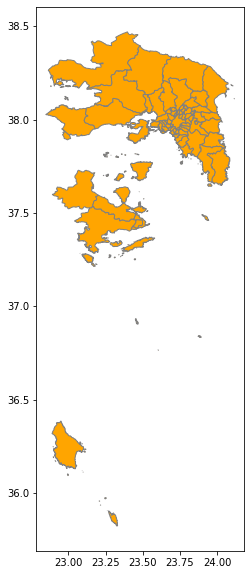

In [9]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [10]:
wrong_list = ['Τανάγρας' ,'Θηβαίων', 'Λουτρακίου - Αγ. Θεοδώρων', 'Ερμιονίδας', 'Επιδαύρου']

nuts2_gdf = nuts2_gdf[~nuts2_gdf['NAME'].isin(wrong_list)].copy()

In [11]:
nuts2_gdf.head(5)

,NAME,KWD_YPES,geometry
0,Ιλίου,9182,"POLYGON ((23.68392 38.06429, 23.68763 38.06131..."
1,Ύδρας,9214,"MULTIPOLYGON (((23.40645 37.29497, 23.40642 37..."
2,Αίγινας,9208,"MULTIPOLYGON (((23.31935 37.80028, 23.31914 37..."
3,Αγίας Βαρβάρας,9179,"POLYGON ((23.64394 37.99855, 23.64396 37.99856..."
4,Αγίας Παρασκευής,9167,"POLYGON ((23.84009 38.02410, 23.84021 38.02408..."


In [12]:
nuts2_gdf.drop(columns=['KWD_YPES'], inplace = True)
nuts2_gdf.rename(columns={"NAME": "lau1"}, inplace = True)
process_greek(nuts2_gdf, 'lau1')

In [13]:
nuts2_gdf.head(5)

,lau1,geometry
0,ιλιου,"POLYGON ((23.68392 38.06429, 23.68763 38.06131..."
1,υδρας,"MULTIPOLYGON (((23.40645 37.29497, 23.40642 37..."
2,αιγινας,"MULTIPOLYGON (((23.31935 37.80028, 23.31914 37..."
3,αγιας βαρβαρας,"POLYGON ((23.64394 37.99855, 23.64396 37.99856..."
4,αγιας παρασκευης,"POLYGON ((23.84009 38.02410, 23.84021 38.02408..."


<AxesSubplot:>

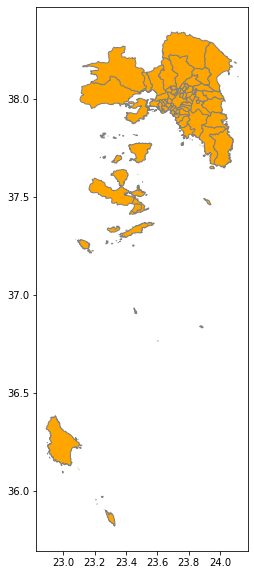

In [14]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [15]:
indexes = []

nuts2 = nuts2_gdf

for index, row in rivers_gdf.iterrows():
    for index2, row2 in nuts2.iterrows():
                    
        if row['geometry'].intersects(row2['geometry']):
                indexes.append(index)

nuts2_rivers_gdf = rivers_gdf.loc[indexes].reset_index(drop=True)

In [16]:
nuts2_rivers_gdf.head()

,objectid,eu_cd,name,altname1,altname2,altname3,region_cd,system,ins_when,ins_by,...,acid_neut,substratum,chloride,a_temp_rge,av_a_temp,ppt,dist_sourc,cont,shape_Leng,geometry
0,9,None,Unknown,Unknown,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,2499.061150,"LINESTRING (24.02301 38.15953, 24.02301 38.159..."
1,12,None,Unknown,Unknown,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,3917.094155,"LINESTRING (23.82103 38.07738, 23.81889 38.077..."
2,12,None,Unknown,Unknown,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,3917.094155,"LINESTRING (23.82103 38.07738, 23.81889 38.077..."
3,12,None,Unknown,Unknown,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,3917.094155,"LINESTRING (23.82103 38.07738, 23.81889 38.077..."
4,25,None,ÊÑÕÖÔÇ Ñ.,KRYFTH R.,None,None,None,None,None,None,...,None,None,None,None,0.0,0.0,0.0,no,4186.529821,"LINESTRING (23.31597 38.08893, 23.31597 38.088..."


<AxesSubplot:>

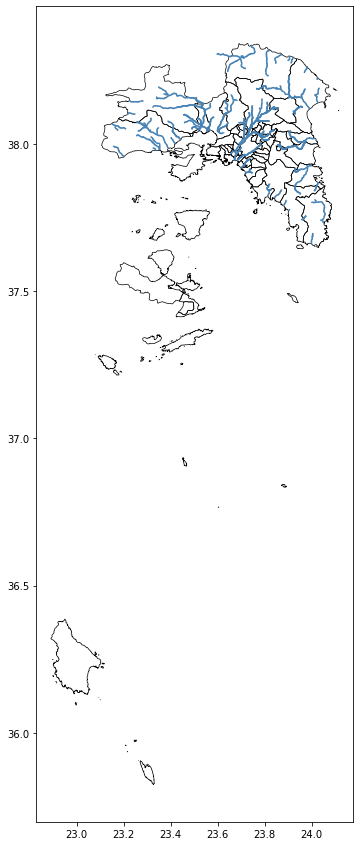

In [17]:
ax = nuts2_rivers_gdf.plot(markersize=.1, figsize=(15, 15), cmap='jet', color='steelblue')
nuts2.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.7)

In [18]:
lau1_units = nuts2_gdf['lau1'].unique().tolist()

with open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_SHP_LAU1_Units_Processed.txt', 'w', encoding=enc) as f:
    for item in lau1_units:
        f.write("%s\n" % item)

print(f"Number of LAU1 Units in {NUTS2} (from shapefile): {len(lau1_units)}")

Number of LAU1 Units in Attica (from shapefile): 66


In [19]:
nuts2_gdf.reset_index(inplace=True, drop = True)
nuts2_rivers_gdf.reset_index(inplace=True, drop=True)

In [21]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, nuts2, col_municipal='lau1', dimension=2.5)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

e:\Drive\NOA\MBD-Prediction\Greece\notebooks\Attica\../../../Modules\utils.py:671: FutureWarning: Currently, index_parts defaults to True, but in the future, it will default to False to be consistent with Pandas. Use `index_parts=True` to keep the current behavior and True/False to silence the warning.
  river_shapes_list =  river_shapes[col_geometry].geometry.explode().tolist()
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\pandas\core\dtypes\cast.py:118: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely

In [22]:
df_grid.rename(columns={"NAME": "lau1"}, inplace = True)

<AxesSubplot:>

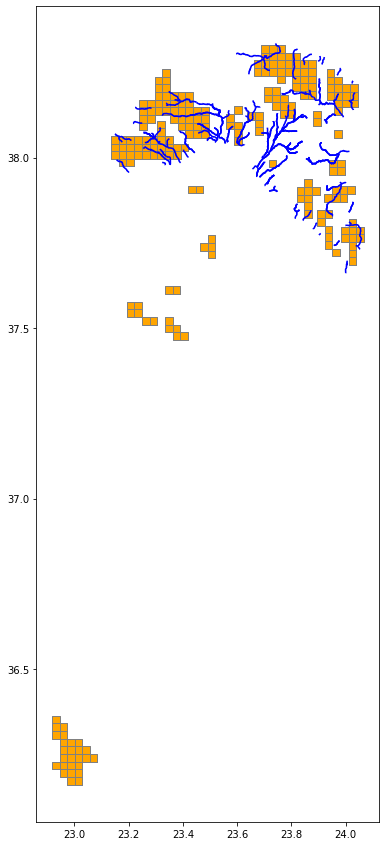

In [23]:
ax = nuts2_rivers_gdf.plot(markersize=.1, figsize=(15, 15), cmap='jet', color='blue')
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [24]:
grid_lau1 = df_grid['lau1'].unique().tolist()
print(f"Number of LAU1 Units in Grid: {len(grid_lau1)}")

Number of LAU1 Units in Grid: 18


['ιλιου', 'υδρας', 'αγιας βαρβαρας', 'αγιας παρασκευης', 'αγιου δημητριου', 'αγιων αναργυρων καματερου', 'αγκιστριου', 'αιγαλεω', 'αλιμου', 'αμαρουσιου', 'βαρης βουλας βουλιαγμενης', 'βριλησσιων', 'βυρωνος', 'γαλατσιου', 'γλυφαδας', 'δαφνης υμηττου', 'ελευσινας', 'ελληνικου αργυρουπολης', 'ζωγραφου', 'ηλιουπολης', 'ηρακλειου', 'καισαριανης', 'καλλιθεας', 'κερατσινιου δραπετσωνας', 'κηφισιας', 'κορυδαλλου', 'λυκοβρυσης πευκης', 'μεταμορφωσεως', 'μοσχατου ταυρου', 'νεας ιωνιας', 'νεας σμυρνης', 'νικαιας αγιου ι. ρεντη', 'παιανιας', 'παλαιου φαληρου', 'παλληνης', 'παπαγου χολαργου', 'πειραιως', 'πεντελης', 'περαματος', 'περιστεριου', 'πετρουπολης', 'πορου', 'ραφηνας πικερμιου', 'σπετσων', 'φιλαδελφειας χαλκηδονος', 'φιλοθεης ψυχικου', 'χαϊδαριου', 'χαλανδριου']


C:\Users\dimit\AppData\Local\Temp/ipykernel_1672/781339209.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lost_lau1["centroid"] = lost_lau1["geometry"].centroid
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\geodataframe.py:1472: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


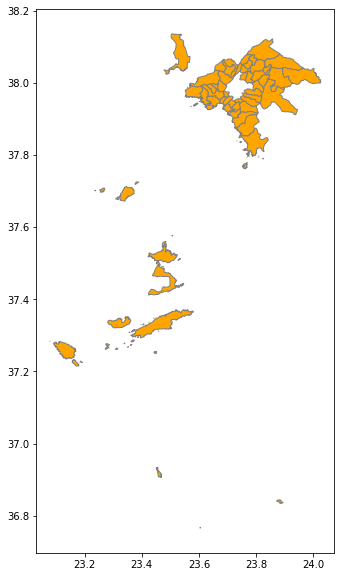

In [25]:
if (len(lau1_units) != len(grid_lau1)):
    delta = [item for item in lau1_units if item not in grid_lau1]
    print(delta)

    lost_lau1 = nuts2[nuts2['lau1'].isin(delta)]
    lost_lau1["centroid"] = lost_lau1["geometry"].centroid

    add_to_nuts2_grid = pd.DataFrame()
    add_to_nuts2_grid['lau1'] = lost_lau1['lau1']
    add_to_nuts2_grid['geometry'] = lost_lau1['geometry']
    add_to_nuts2_grid['x'] = round(lost_lau1['centroid'].x, 5)
    add_to_nuts2_grid['y'] = round(lost_lau1['centroid'].y, 5)

    lost_lau1.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [26]:
nuts2_grid = df_grid.drop(columns=['centers'])

In [27]:
nuts2_grid

,geometry,lau1,x,y
0,"POLYGON ((23.49155 37.72720, 23.49155 37.74966...",αιγινας,23.47738,37.73843
1,"POLYGON ((23.51990 37.70474, 23.51990 37.72720...",αιγινας,23.50573,37.71597
2,"POLYGON ((23.51990 37.72720, 23.51990 37.74966...",αιγινας,23.50573,37.73843
3,"POLYGON ((23.51990 37.74966, 23.51990 37.77212...",αιγινας,23.50573,37.76089
4,"POLYGON ((23.74415 37.97145, 23.74415 37.99391...",αθηναιων,23.72991,37.98268
...,...,...,...,...
219,"POLYGON ((23.88916 38.17309, 23.88916 38.19554...",ωρωπου,23.87488,38.18432
220,"POLYGON ((23.88916 38.19554, 23.88916 38.21800...",ωρωπου,23.87488,38.20677
221,"POLYGON ((23.88916 38.21800, 23.88916 38.24046...",ωρωπου,23.87488,38.22923
222,"POLYGON ((23.88916 38.24046, 23.88916 38.26292...",ωρωπου,23.87488,38.25169


In [28]:
if (len(lau1_units) != len(grid_lau1)):
    nuts2_grid = pd.concat([nuts2_grid, add_to_nuts2_grid], axis=0)

nuts2_grid.reset_index(inplace=True, drop=True)

In [29]:
nuts2_grid['nuts2'] = NUTS2_EL

In [30]:
nuts2_grid.rename(columns={"geometry": "shape"}, inplace=True)

In [31]:
nuts2_grid

,shape,lau1,x,y,nuts2
0,"POLYGON ((23.49155 37.72720, 23.49155 37.74966...",αιγινας,23.47738,37.73843,αττικης
1,"POLYGON ((23.51990 37.70474, 23.51990 37.72720...",αιγινας,23.50573,37.71597,αττικης
2,"POLYGON ((23.51990 37.72720, 23.51990 37.74966...",αιγινας,23.50573,37.73843,αττικης
3,"POLYGON ((23.51990 37.74966, 23.51990 37.77212...",αιγινας,23.50573,37.76089,αττικης
4,"POLYGON ((23.74415 37.97145, 23.74415 37.99391...",αθηναιων,23.72991,37.98268,αττικης
...,...,...,...,...,...
267,"MULTIPOLYGON (((23.87137 36.84091, 23.87159 36...",σπετσων,23.18864,37.21543,αττικης
268,"POLYGON ((23.72177 38.01826, 23.71958 38.01599...",φιλαδελφειας χαλκηδονος,23.73834,38.03938,αττικης
269,"POLYGON ((23.78121 38.00972, 23.78145 38.00970...",φιλοθεης ψυχικου,23.77628,38.01477,αττικης
270,"POLYGON ((23.65604 38.03663, 23.65608 38.03649...",χαϊδαριου,23.63084,38.00942,αττικης


In [32]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

In [33]:
nuts2_grid_points

,shape,lau1,x,y,nuts2,geometry
0,"POLYGON ((23.49155 37.72720, 23.49155 37.74966...",αιγινας,23.47738,37.73843,αττικης,POINT (23.47738 37.73843)
1,"POLYGON ((23.51990 37.70474, 23.51990 37.72720...",αιγινας,23.50573,37.71597,αττικης,POINT (23.50573 37.71597)
2,"POLYGON ((23.51990 37.72720, 23.51990 37.74966...",αιγινας,23.50573,37.73843,αττικης,POINT (23.50573 37.73843)
3,"POLYGON ((23.51990 37.74966, 23.51990 37.77212...",αιγινας,23.50573,37.76089,αττικης,POINT (23.50573 37.76089)
4,"POLYGON ((23.74415 37.97145, 23.74415 37.99391...",αθηναιων,23.72991,37.98268,αττικης,POINT (23.72991 37.98268)
...,...,...,...,...,...,...
267,"MULTIPOLYGON (((23.87137 36.84091, 23.87159 36...",σπετσων,23.18864,37.21543,αττικης,POINT (23.18864 37.21543)
268,"POLYGON ((23.72177 38.01826, 23.71958 38.01599...",φιλαδελφειας χαλκηδονος,23.73834,38.03938,αττικης,POINT (23.73834 38.03938)
269,"POLYGON ((23.78121 38.00972, 23.78145 38.00970...",φιλοθεης ψυχικου,23.77628,38.01477,αττικης,POINT (23.77628 38.01477)
270,"POLYGON ((23.65604 38.03663, 23.65608 38.03649...",χαϊδαριου,23.63084,38.00942,αττικης,POINT (23.63084 38.00942)


<AxesSubplot:>

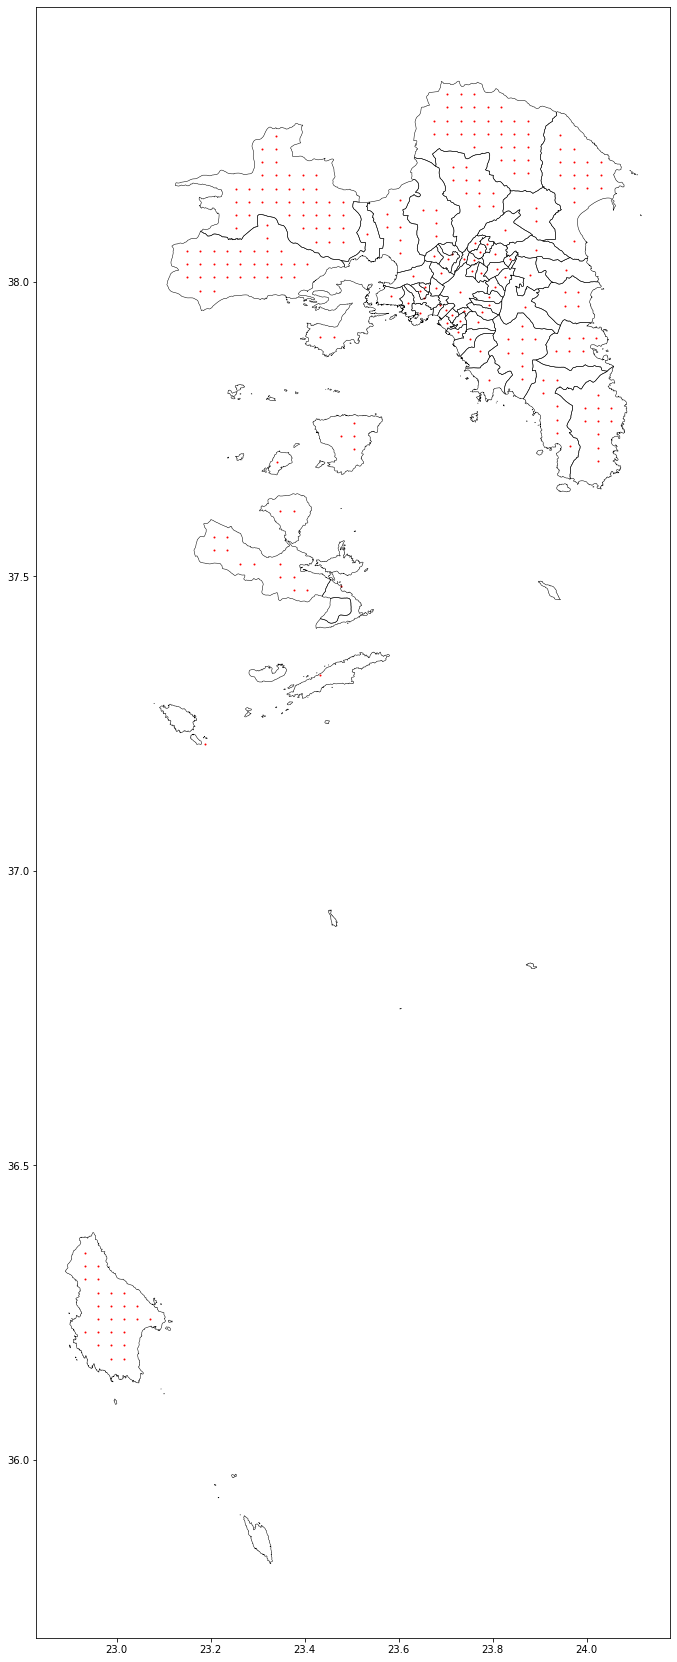

In [35]:
ax = nuts2_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
nuts2.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
#nuts2_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [36]:
value_counts = nuts2_grid['lau1'].value_counts().sort_values()

In [37]:
arr = value_counts.values

In [38]:
arr_norm = np.ceil((15*(arr - np.min(arr) + 1 )/np.ptp(arr))).astype(int)

In [39]:
value_counts_target = pd.Series(data=arr_norm, index=value_counts.index)

In [40]:
value_counts_target

περιστεριου                 1
ραφηνας πικερμιου           1
σπετσων                     1
κερατσινιου δραπετσωνας     1
φιλοθεης ψυχικου            1
                           ..
μαραθωνος                   6
κυθηρων                    10
μεγαρεων                   12
ωρωπου                     13
μανδρας ειδυλλιας          16
Length: 66, dtype: int32

In [41]:
idx = []
points = [] 

for index, value in value_counts_target.iteritems():
    if value == value_counts[index]:
        pass
    else: 
        idx.append(index)
        points.append(value_counts[index] - value)
        print(f'Index: {index} || Value: {value_counts[index]} || Target Value: {value}')

Index: σαλαμινας || Value: 2 || Target Value: 1
Index: διονυσου || Value: 2 || Target Value: 1
Index: σπατων αρτεμιδος || Value: 4 || Target Value: 2
Index: φυλης || Value: 4 || Target Value: 2
Index: αιγινας || Value: 4 || Target Value: 2
Index: μαρκοπουλου μεσογαιας || Value: 6 || Target Value: 3
Index: ασπροπυργου || Value: 6 || Target Value: 3
Index: σαρωνικου || Value: 7 || Target Value: 3
Index: κρωπιας || Value: 8 || Target Value: 3
Index: λαυρεωτικης || Value: 10 || Target Value: 4
Index: αχαρνων || Value: 10 || Target Value: 4
Index: τροιζηνιας || Value: 13 || Target Value: 5
Index: μαραθωνος || Value: 16 || Target Value: 6
Index: κυθηρων || Value: 26 || Target Value: 10
Index: μεγαρεων || Value: 31 || Target Value: 12
Index: ωρωπου || Value: 33 || Target Value: 13
Index: μανδρας ειδυλλιας || Value: 41 || Target Value: 16


In [42]:
to_remove = pd.Series(data=points, index=idx)

In [43]:
to_remove

σαλαμινας                 1
διονυσου                  1
σπατων αρτεμιδος          2
φυλης                     2
αιγινας                   2
μαρκοπουλου μεσογαιας     3
ασπροπυργου               3
σαρωνικου                 4
κρωπιας                   5
λαυρεωτικης               6
αχαρνων                   6
τροιζηνιας                8
μαραθωνος                10
κυθηρων                  16
μεγαρεων                 19
ωρωπου                   20
μανδρας ειδυλλιας        25
dtype: int64

In [44]:
## removes some points

# indicies_to_remove = []

# for municipality, points in to_remove.iteritems():
#     indicies = nuts2_grid.loc[nuts2_grid['lau1'] ==  municipality].index.tolist()
#     to_removed = random.sample(indicies, points)
#     for item in to_removed:
#         indicies_to_remove.append(item)

# nuts2_grid.drop(index = indicies_to_remove, axis = 1, inplace = True)
# nuts2_grid.reset_index(inplace = True, drop = True)

In [45]:
attica_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

<AxesSubplot:>

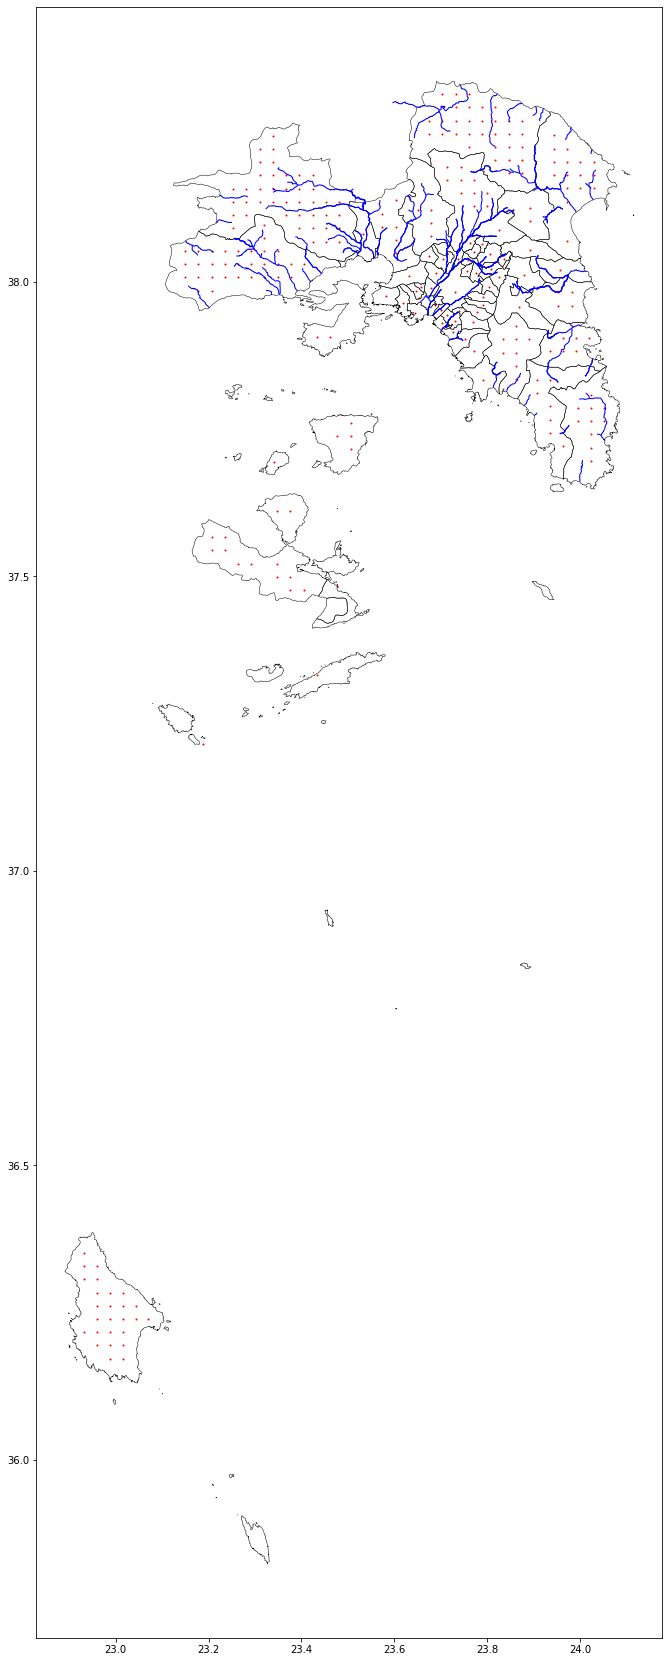

In [46]:
ax = attica_grid_points.plot(markersize=1, figsize=(30, 30), color='red')
nuts2.plot(facecolor="none", edgecolor='black', ax=ax, lw=0.5)
nuts2_rivers_gdf.plot(facecolor="none", edgecolor='blue', ax=ax, lw=1)

In [47]:
len(nuts2_grid['lau1'].unique())

66

In [48]:
nuts2_grid

,shape,lau1,x,y,nuts2,geometry
0,"POLYGON ((23.49155 37.72720, 23.49155 37.74966...",αιγινας,23.47738,37.73843,αττικης,POINT (23.47738 37.73843)
1,"POLYGON ((23.51990 37.70474, 23.51990 37.72720...",αιγινας,23.50573,37.71597,αττικης,POINT (23.50573 37.71597)
2,"POLYGON ((23.51990 37.72720, 23.51990 37.74966...",αιγινας,23.50573,37.73843,αττικης,POINT (23.50573 37.73843)
3,"POLYGON ((23.51990 37.74966, 23.51990 37.77212...",αιγινας,23.50573,37.76089,αττικης,POINT (23.50573 37.76089)
4,"POLYGON ((23.74415 37.97145, 23.74415 37.99391...",αθηναιων,23.72991,37.98268,αττικης,POINT (23.72991 37.98268)
...,...,...,...,...,...,...
267,"MULTIPOLYGON (((23.87137 36.84091, 23.87159 36...",σπετσων,23.18864,37.21543,αττικης,POINT (23.18864 37.21543)
268,"POLYGON ((23.72177 38.01826, 23.71958 38.01599...",φιλαδελφειας χαλκηδονος,23.73834,38.03938,αττικης,POINT (23.73834 38.03938)
269,"POLYGON ((23.78121 38.00972, 23.78145 38.00970...",φιλοθεης ψυχικου,23.77628,38.01477,αττικης,POINT (23.77628 38.01477)
270,"POLYGON ((23.65604 38.03663, 23.65608 38.03649...",χαϊδαριου,23.63084,38.00942,αττικης,POINT (23.63084 38.00942)


In [49]:
final_grid = nuts2_grid[['nuts2', 'lau1', 'x', 'y']].sort_values(by=['lau1'])

In [50]:
final_grid

,nuts2,lau1,x,y
226,αττικης,αγιας βαρβαρας,23.65697,37.99220
227,αττικης,αγιας παρασκευης,23.82642,38.00806
228,αττικης,αγιου δημητριου,23.73031,37.93357
229,αττικης,αγιων αναργυρων καματερου,23.71341,38.04721
230,αττικης,αγκιστριου,23.34009,37.69503
...,...,...,...,...
219,αττικης,ωρωπου,23.87488,38.18432
220,αττικης,ωρωπου,23.87488,38.20677
221,αττικης,ωρωπου,23.87488,38.22923
223,αττικης,ωρωπου,23.87488,38.27415


In [51]:
final_grid.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Grid.csv', encoding=enc, index = False)